In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
df = sns.load_dataset("titanic")
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [4]:
df.isnull().sum()

,0
survived,0
pclass,0
sex,0
age,177
sibsp,0
parch,0
fare,0
embarked,2
class,0
who,0


In [5]:
df.dropna(subset = ["embarked"], inplace = True)
df.dropna(subset = ["embark_town"], inplace = True)
df.isnull().sum()

,0
survived,0
pclass,0
sex,0
age,177
sibsp,0
parch,0
fare,0
embarked,0
class,0
who,0


In [6]:
df["age"] = df["age"].fillna(df["age"].median())
df.isnull().sum()

,0
survived,0
pclass,0
sex,0
age,0
sibsp,0
parch,0
fare,0
embarked,0
class,0
who,0


In [7]:
df.drop(columns = ["deck"], inplace = True)
df.drop(columns = ["alive"], inplace = True)
df.drop(columns = ["alone"], inplace = True)
df.drop(columns = ["embark_town"], inplace = True)
df.drop(columns = ["adult_male"], inplace = True)
df.drop(columns = ["who"], inplace = True)
df.drop(columns = ["class"], inplace = True)
df.drop(columns = ["embarked"], inplace = True)
df.head()

,survived,pclass,sex,age,sibsp,parch,fare
0,0,3,male,22.0,1,0,7.2500
1,1,1,female,38.0,1,0,71.2833
2,1,3,female,26.0,0,0,7.9250
3,1,1,female,35.0,1,0,53.1000
4,0,3,male,35.0,0,0,8.0500


In [8]:
df.reset_index()

,index,survived,pclass,sex,age,sibsp,parch,fare
0,0,0,3,male,22.0,1,0,7.2500
1,1,1,1,female,38.0,1,0,71.2833
2,2,1,3,female,26.0,0,0,7.9250
3,3,1,1,female,35.0,1,0,53.1000
4,4,0,3,male,35.0,0,0,8.0500
...,...,...,...,...,...,...,...,...
884,886,0,2,male,27.0,0,0,13.0000
885,887,1,1,female,19.0,0,0,30.0000
886,888,0,3,female,28.0,1,2,23.4500
887,889,1,1,male,26.0,0,0,30.0000


In [9]:
df.duplicated().sum()

np.int64(119)

In [10]:
df[df.duplicated()]

,survived,pclass,sex,age,sibsp,parch,fare
42,0,3,male,28.0,0,0,7.8958
47,1,3,female,28.0,0,0,7.7500
55,1,1,male,28.0,0,0,35.5000
76,0,3,male,28.0,0,0,7.8958
77,0,3,male,28.0,0,0,8.0500
...,...,...,...,...,...,...,...
877,0,3,male,19.0,0,0,7.8958
878,0,3,male,28.0,0,0,7.8958
881,0,3,male,33.0,0,0,7.8958
884,0,3,male,25.0,0,0,7.0500


In [11]:
df.drop_duplicates(inplace = True)
df.duplicated().sum()

np.int64(0)

Feature engineering

In [12]:
df["family_size"] = df["sibsp"] + df["parch"] + 1
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,family_size
0,0,3,male,22.0,1,0,7.2500,2
1,1,1,female,38.0,1,0,71.2833,2
2,1,3,female,26.0,0,0,7.9250,1
3,1,1,female,35.0,1,0,53.1000,2
4,0,3,male,35.0,0,0,8.0500,1


Standardize age and fare to remove the effect of scales

In [13]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()

df["age"] = scaler.fit_transform(df[["age"]])
df["fare"] = scaler.fit_transform(df[["fare"]])
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,family_size
0,0,3,male,0.271174,1,0,0.014151,2
1,1,1,female,0.472229,1,0,0.139136,2
2,1,3,female,0.321438,0,0,0.015469,1
3,1,1,female,0.434531,1,0,0.103644,2
4,0,3,male,0.434531,0,0,0.015713,1


Using label encoder for turning sex into categorical variables because it has two categories

In [14]:
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()

df["sex"] = encoder.fit_transform(df["sex"])

df.head()

,survived,pclass,sex,age,sibsp,parch,fare,family_size
0,0,3,1,0.271174,1,0,0.014151,2
1,1,1,0,0.472229,1,0,0.139136,2
2,1,3,0,0.321438,0,0,0.015469,1
3,1,1,0,0.434531,1,0,0.103644,2
4,0,3,1,0.434531,0,0,0.015713,1


Using one-hot encoding for converting embarked into categorical variables because it contains more than 2 categories

Randomize the dataset to prevent bias

In [15]:
df = df.sample(frac = 1, random_state = 42).reset_index(drop = True)  #frac = 1 shuffles all the rows
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,family_size
0,0,3,1,0.346569,1,0,0.047138,2
1,0,1,1,0.384267,0,0,0.098561,1
2,1,1,0,0.484795,1,1,0.162314,3
3,0,3,1,0.535059,0,0,0.015713,1
4,1,1,0,0.346569,1,0,0.173920,2


Where we build the model

In [16]:
Y = df["survived"]
X = df.drop(columns = ["survived"])

In [17]:
df["survived"].value_counts()

,count
survived,
0,453
1,317


In [18]:
X = df[["pclass", "sex", "age", "sibsp", "parch", "fare", "family_size"]]
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,family_size
0,0,3,1,0.346569,1,0,0.047138,2
1,0,1,1,0.384267,0,0,0.098561,1
2,1,1,0,0.484795,1,1,0.162314,3
3,0,3,1,0.535059,0,0,0.015713,1
4,1,1,0,0.346569,1,0,0.173920,2


Splitting data into test and train. 80% train and 20% test

In [19]:
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [20]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size = 0.2, random_state = 42)
#random_state=42 uses the same sequence of random choices everytime so the model accuracy stays the same throughout unless you alter something

tree = DecisionTreeClassifier(max_depth = 3, criterion = "entropy", random_state = 42) #max_depth determines how many levels deep the decision tree can grow
                                                                                   #can also use gini for criterion

In [21]:
tree.fit(X_train, Y_train)

DecisionTreeClassifier(criterion='entropy', max_depth=3, random_state=42)

In [22]:
Y_pred = tree.predict(X_test)

In [23]:
train_acc = accuracy_score(Y_train, tree.predict(X_train))
test_acc = accuracy_score(Y_test, tree.predict(X_test))

In [24]:
print(f"Training Accuracy: {train_acc}")
print(f"Training Accuracy: {train_acc:.1%}")

Training Accuracy: 0.8051948051948052
Training Accuracy: 80.5%


In [25]:
print(f"Testing Accuracy: {test_acc}")
print(f"Testing Accuracy: {test_acc:.1%}")

Testing Accuracy: 0.8246753246753247
Testing Accuracy: 82.5%


In [26]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,family_size
0,0,3,1,0.346569,1,0,0.047138,2
1,0,1,1,0.384267,0,0,0.098561,1
2,1,1,0,0.484795,1,1,0.162314,3
3,0,3,1,0.535059,0,0,0.015713,1
4,1,1,0,0.346569,1,0,0.173920,2


Testing our prediction accuracy

In [27]:
new_passenger = [[1, 0, 0.484795, 1, 1, 0.162314, 3]]

prediction = tree.predict(new_passenger)

if prediction == 1:
                   print(f"Prediction: Survived {prediction}")
else:
     print(f"Prediction: Deceased {prediction}")

probability = tree.predict_proba(new_passenger)

print(f"Probability of surviving: {probability[0][1]:.1%}")
print(f"probability of not surviving: {probability[0][0]:.1%}")

Prediction: Survived [1]
Probability of surviving: 95.4%
probability of not surviving: 4.6%


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


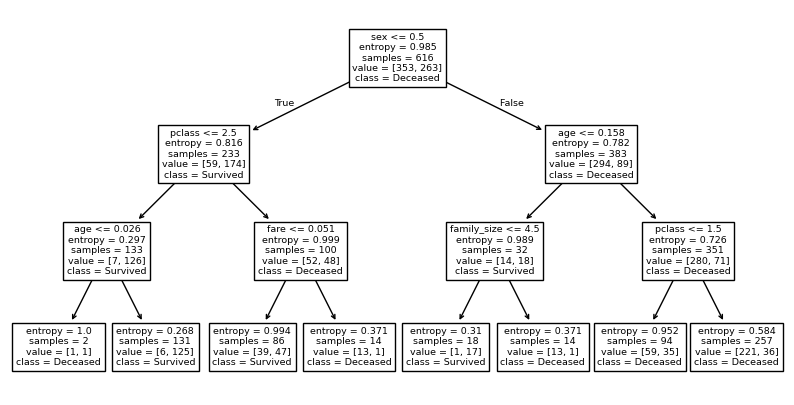

In [28]:
fig, ax = plt.subplots(figsize = (10, 5))

plot_tree(
    tree,
    feature_names = X.columns,
    class_names = ["Deceased", "Survived"],
    ax = ax
)
plt.show()

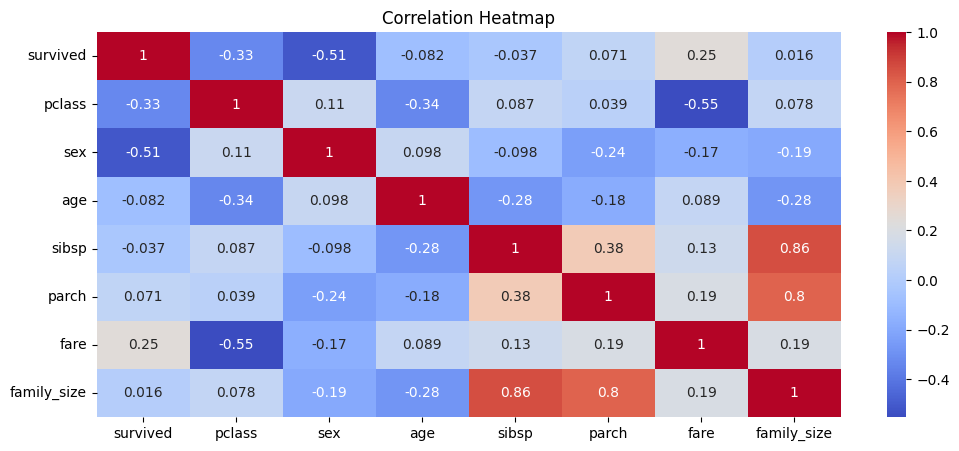

In [29]:
corr_matrix = df.corr(numeric_only = True)
plt.figure(figsize = (12,5))
sns.heatmap(corr_matrix, annot = True, cmap = "coolwarm")
plt.title("Correlation Heatmap")
plt.show()

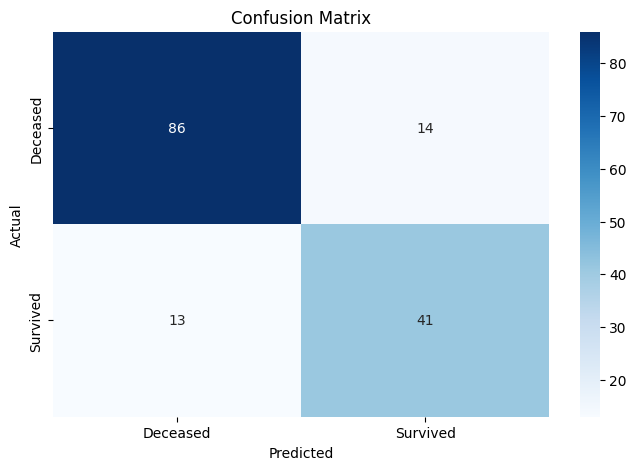

In [32]:
cm = confusion_matrix(Y_test, Y_pred)
plt.figure(figsize = (8, 5))
sns.heatmap(cm, annot = True, fmt = "d", cmap = "Blues", xticklabels = ["Deceased", "Survived"], yticklabels = ["Deceased", "Survived"])
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [33]:
print(classification_report(Y_test, Y_pred))

              precision    recall  f1-score   support

           0       0.87      0.86      0.86       100
           1       0.75      0.76      0.75        54

    accuracy                           0.82       154
   macro avg       0.81      0.81      0.81       154
weighted avg       0.83      0.82      0.83       154

